# 📊 Industry-Oriented Sales Forecasting & Revenue Prediction System
**Project 2 | Data Science | Python + Pandas + NumPy + Matplotlib + Seaborn + Scikit-learn**

---
This notebook walks through every stage of the forecasting pipeline interactively.

In [1]:
# ── Install missing packages (run once) ────────────────────────────────────
# Uncomment the line below if any package is missing:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import warnings; warnings.filterwarnings('ignore')
import os, sys
sys.path.insert(0, os.getcwd())
import matplotlib
matplotlib.use('inline')          # Jupyter inline mode
%matplotlib inline

from sales_forecasting import (
    generate_sales_data, preprocess,
    plot_sales_overview, plot_seasonality, plot_revenue_breakdown,
    plot_trend_decomposition, train_and_evaluate,
    plot_forecasts, plot_model_comparison,
    plot_feature_importance, plot_30day_future_forecast,
    generate_insights_report
)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
print('✅ Imports OK')

✅ Imports OK


## 1 · Dataset Generation

In [2]:
raw_df = generate_sales_data(n_years=3)
print('Shape:', raw_df.shape)
raw_df.head(10)

[✓] Dataset generated: 5,480 rows × 10 cols
Shape: (5480, 10)


,date,category,sales_amount,units_sold,profit,is_promotion,day_of_week,month,quarter,year
0,2022-01-01,Electronics,39994.19,2352,18182.61,False,5,1,1,2022
1,2022-01-02,Electronics,37892.49,2228,17227.11,False,6,1,1,2022
2,2022-01-03,Electronics,35746.14,2102,16251.31,False,0,1,1,2022
3,2022-01-04,Electronics,38921.73,2289,17695.04,False,1,1,1,2022
4,2022-01-05,Electronics,36257.55,2132,16483.82,True,2,1,1,2022
5,2022-01-06,Electronics,36388.22,2140,16543.22,True,3,1,1,2022
6,2022-01-07,Electronics,39474.57,2321,17946.38,False,4,1,1,2022
7,2022-01-08,Electronics,45788.17,2692,20816.74,True,5,1,1,2022
8,2022-01-09,Electronics,37688.83,2216,17134.52,False,6,1,1,2022
9,2022-01-10,Electronics,36232.91,2130,16472.62,False,0,1,1,2022


In [3]:
print(raw_df.dtypes)
print('\nMissing values:\n', raw_df.isnull().sum())
raw_df.describe()

date            datetime64[us]
category                   str
sales_amount           float64
units_sold               int64
profit                 float64
is_promotion              bool
day_of_week              int32
month                    int64
quarter                  int64
year                     int64
dtype: object

Missing values:
 date            0
category        0
sales_amount    0
units_sold      0
profit          0
is_promotion    0
day_of_week     0
month           0
quarter         0
year            0
dtype: int64


,date,sales_amount,units_sold,profit,day_of_week,month,quarter,year
count,5480,5480.000000,5480.000000,5480.000000,5480.000000,5480.000000,5480.000000,5480.000000
mean,2023-07-02 12:00:00,59503.878881,1726.507299,27153.859821,3.000000,6.521898,2.508212,2023.000912
min,2022-01-01 00:00:00,6526.970000,143.000000,3158.650000,0.000000,1.000000,1.000000,2022.000000
25%,2022-10-01 18:00:00,42179.460000,631.000000,18502.697500,1.000000,4.000000,2.000000,2022.000000
50%,2023-07-02 12:00:00,59172.350000,1166.000000,26388.830000,3.000000,7.000000,3.000000,2023.000000
75%,2024-04-01 06:00:00,74960.322500,1584.500000,34930.240000,5.000000,10.000000,4.000000,2024.000000
max,2024-12-31 00:00:00,137333.140000,8075.000000,62435.940000,6.000000,12.000000,4.000000,2024.000000
std,NaN,23018.802379,1693.733247,10875.438308,2.002462,3.449301,1.117289,0.816757


## 2 · Preprocessing & Feature Engineering

In [4]:
df = preprocess(raw_df)
print('After preprocessing shape:', df.shape)
df[['date','category','sales_amount','lag_7','rolling_7','sin_month']].head(8)

[✓] Preprocessing done: 5,330 rows after cleaning
After preprocessing shape: (5330, 22)


,date,category,sales_amount,lag_7,rolling_7,sin_month
30,2022-01-31,Clothing,22926.88,22691.22,22698.777143,0.500000
31,2022-02-01,Clothing,21249.07,22965.06,22732.442857,0.866025
32,2022-02-02,Clothing,24621.19,22021.17,22487.301429,0.866025
33,2022-02-03,Clothing,25359.40,20709.11,22858.732857,0.866025
34,2022-02-04,Clothing,22230.14,21890.12,23523.060000,0.866025
35,2022-02-05,Clothing,25408.62,21921.43,23571.634286,0.866025
36,2022-02-06,Clothing,25545.01,26693.33,24069.804286,0.866025
37,2022-02-07,Clothing,21749.14,22926.88,23905.758571,0.866025


## 3 · Exploratory Data Analysis

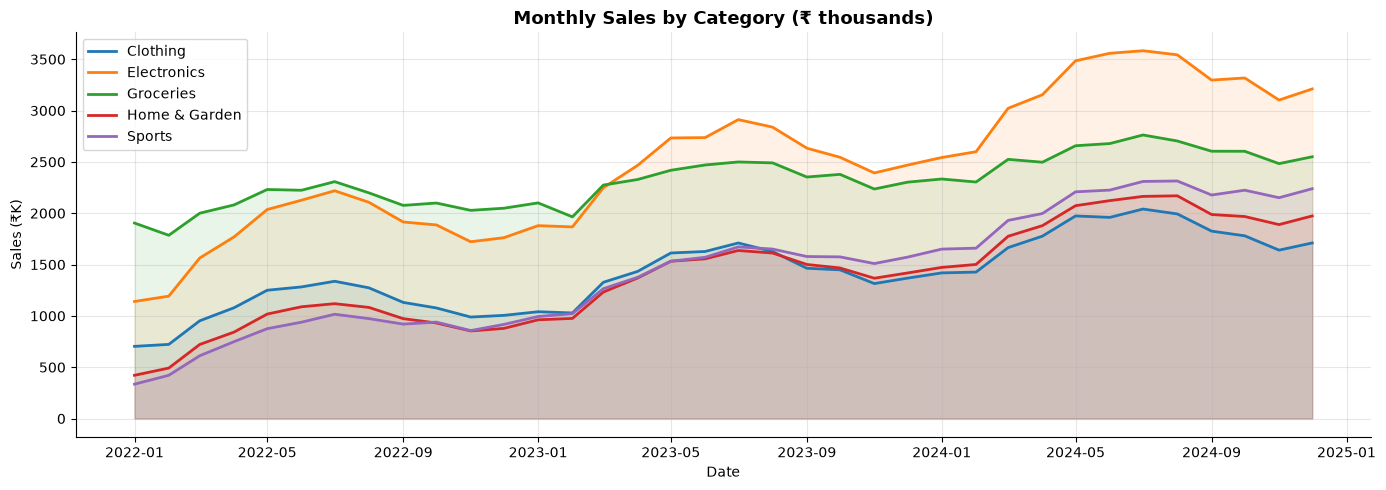

In [5]:
import matplotlib
matplotlib.use('inline')
%matplotlib inline
import matplotlib.pyplot as plt

# Monthly sales trend
monthly = (raw_df.groupby(['year','month','category'])['sales_amount']
                 .sum().reset_index())
monthly['period'] = pd.to_datetime(monthly[['year','month']].assign(day=1))
palette = sns.color_palette('tab10', 5)

fig, ax = plt.subplots(figsize=(14,5))
for i, (cat, grp) in enumerate(monthly.groupby('category')):
    ax.plot(grp['period'], grp['sales_amount']/1000,
            label=cat, color=palette[i], linewidth=2)
    ax.fill_between(grp['period'], grp['sales_amount']/1000, alpha=0.1, color=palette[i])
ax.set_title('Monthly Sales by Category (₹ thousands)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Sales (₹K)')
ax.legend(); ax.grid(alpha=0.3); sns.despine(ax=ax)
plt.tight_layout(); plt.show()

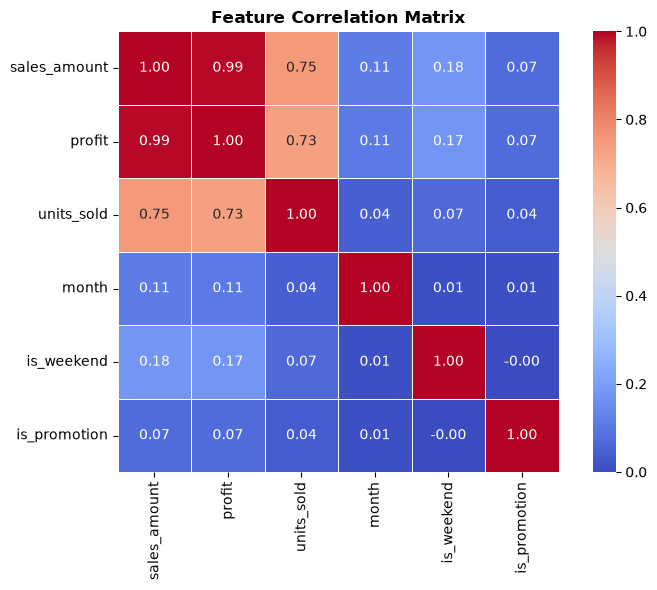

In [6]:
# Correlation heatmap
num_cols = ['sales_amount','profit','units_sold','month','is_weekend','is_promotion']
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

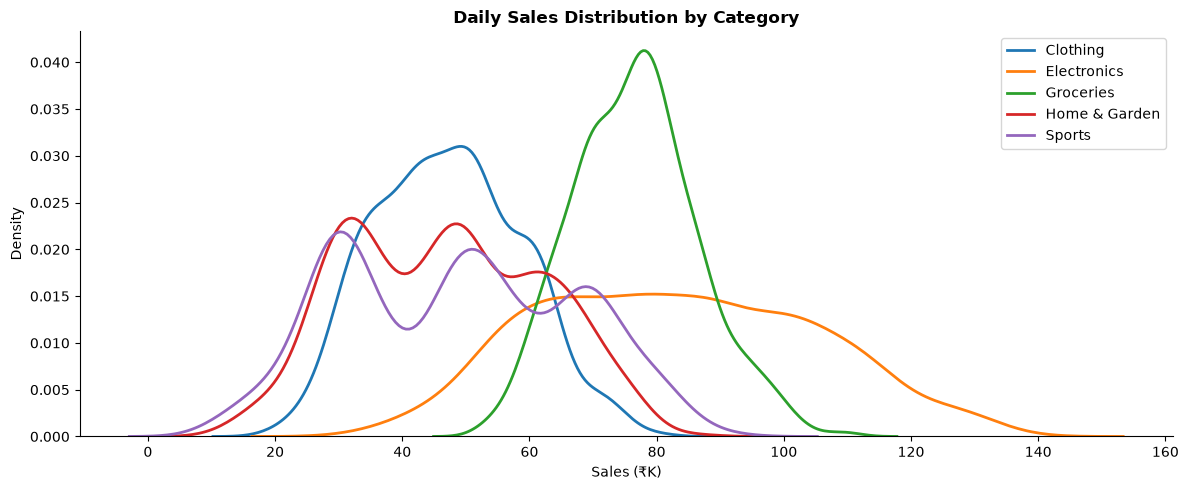

In [7]:
# Distribution of daily sales per category
fig, ax = plt.subplots(figsize=(12,5))
for i, (cat, grp) in enumerate(df.groupby('category')):
    sns.kdeplot(grp['sales_amount']/1000, ax=ax, label=cat,
                color=palette[i], linewidth=2)
ax.set_title('Daily Sales Distribution by Category', fontweight='bold')
ax.set_xlabel('Sales (₹K)'); ax.legend(); sns.despine(ax=ax)
plt.tight_layout(); plt.show()

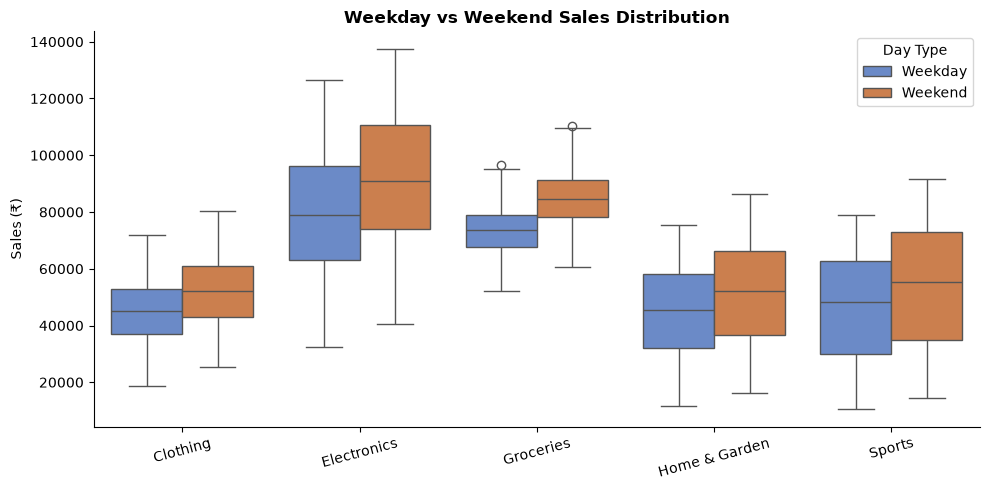

In [8]:
# Weekday vs weekend boxplot
df2 = df.copy()
df2['Day Type'] = df2['is_weekend'].map({0:'Weekday', 1:'Weekend'})
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x='category', y='sales_amount', hue='Day Type', data=df2,
            palette=['#5C85D6','#E07B39'], ax=ax)
ax.set_title('Weekday vs Weekend Sales Distribution', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Sales (₹)'); sns.despine(ax=ax)
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 4 · Model Training & Evaluation

In [9]:
results = train_and_evaluate(df)
metrics = pd.read_csv('outputs/model_metrics.csv')
metrics.style.background_gradient(subset=['R²'], cmap='Greens') \
             .background_gradient(subset=['RMSE'], cmap='Reds_r') \
             .format({'MAE':'{:,.0f}','RMSE':'{:,.0f}','R²':'{:.4f}','MAPE%':'{:.2f}%'})

[✓] Models trained. Metrics saved → outputs/model_metrics.csv


,Category,Model,MAE,RMSE,R²,MAPE%
0,Clothing,Linear Regression,"2,079","2,644",0.8448,3.47%
1,Clothing,Ridge Regression,"2,067","2,628",0.8467,3.45%
2,Clothing,Random Forest,"2,535","3,157",0.7788,4.21%
3,Clothing,Gradient Boosting,"3,032","3,684",0.6987,4.96%
4,Electronics,Linear Regression,"3,110","4,048",0.8393,2.83%
5,Electronics,Ridge Regression,"3,010","3,978",0.8448,2.73%
6,Electronics,Random Forest,"4,640","6,068",0.6388,4.24%
7,Electronics,Gradient Boosting,"4,029","5,096",0.7452,3.64%
8,Groceries,Linear Regression,"3,444","4,344",0.7060,4.03%
9,Groceries,Ridge Regression,"3,411","4,316",0.7099,3.98%


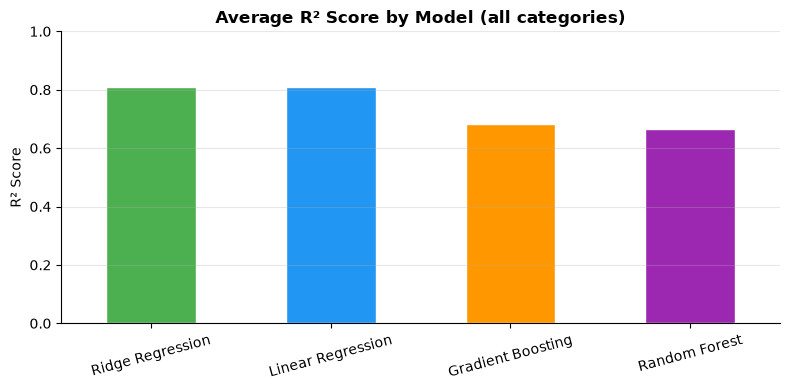

In [10]:
# Per-model average R² bar
avg_r2 = metrics.groupby('Model')['R²'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,4))
avg_r2.plot.bar(ax=ax, color=['#4CAF50','#2196F3','#FF9800','#9C27B0'], edgecolor='white')
ax.set_title('Average R² Score by Model (all categories)', fontweight='bold')
ax.set_ylabel('R² Score'); ax.set_xlabel('')
ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15); sns.despine(ax=ax)
plt.tight_layout(); plt.show()

## 5 · Forecast Visualisations

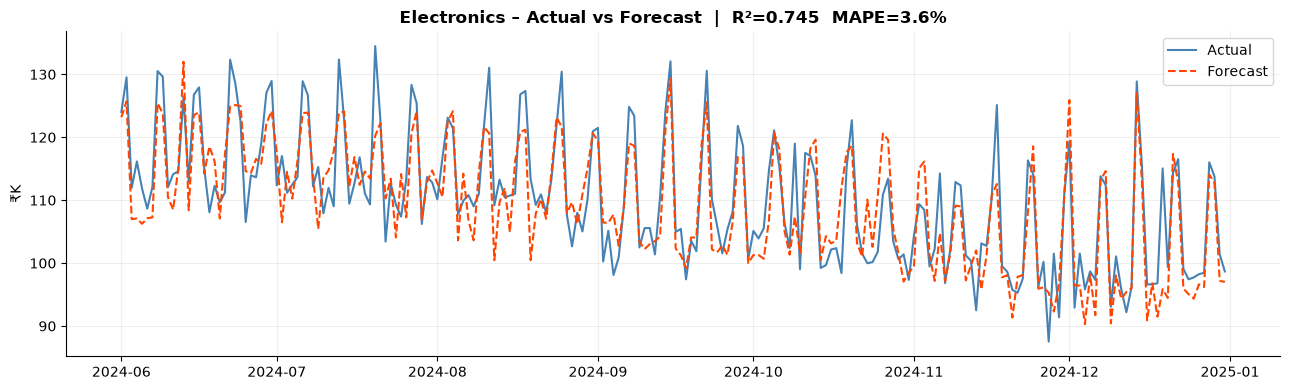

In [11]:
# Actual vs Forecast for one category inline
cat = 'Electronics'
res = results[cat]['Gradient Boosting']
dates = pd.to_datetime(res['dates'])
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(dates, res['y_test']/1000, label='Actual', color='steelblue', linewidth=1.5)
ax.plot(dates, res['preds']/1000, label='Forecast', color='orangered',
        linewidth=1.5, linestyle='--')
ax.set_title(f'{cat} – Actual vs Forecast  |  R²={res["R2"]:.3f}  MAPE={res["MAPE"]:.1f}%',
             fontweight='bold')
ax.set_ylabel('₹K'); ax.legend(); ax.grid(alpha=0.2); sns.despine(ax=ax)
plt.tight_layout(); plt.show()

## 6 · 30-Day Future Forecast

In [12]:
plot_30day_future_forecast(df, results)

  [saved] outputs/08_future_forecast_30days.png


## 7 · Feature Importance

In [13]:
plot_feature_importance(results)

  [saved] outputs/07_feature_importance.png


## 8 · Business Insights Report

In [14]:
generate_insights_report(raw_df, results)
with open('outputs/business_insights_report.txt', 'r', encoding='utf-8') as f:
    print(f.read())

[✓] Business insights report → outputs/business_insights_report.txt

   SALES FORECASTING & REVENUE PREDICTION – BUSINESS INSIGHTS REPORT

EXECUTIVE SUMMARY
------------------------------------------------------------------------
  • Total Revenue (3-Year Dataset)  : ₹326,081,256
  • Total Profit                    : ₹148,803,152
  • Overall Profit Margin           : 45.6%
  • Top Revenue Category            : Electronics
  • Peak Sales Month (avg)          : July

CATEGORY PERFORMANCE
------------------------------------------------------------------------
  1. Electronics      Revenue: ₹  89,575,110  Profit: ₹ 40,723,649  Margin: 45.5%
  2. Groceries        Revenue: ₹  83,502,968  Profit: ₹ 39,521,378  Margin: 47.3%
  3. Sports           Revenue: ₹  51,959,794  Profit: ₹ 25,145,308  Margin: 48.4%
  4. Clothing         Revenue: ₹  51,015,847  Profit: ₹ 21,934,249  Margin: 43.0%
  5. Home & Garden    Revenue: ₹  50,027,537  Profit: ₹ 21,478,567  Margin: 42.9%

TREND & SEASONALITY INSIG